# G2. Synthetic Data Generation

**Authors:** Ivo Rambaldi and Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

## What this notebook does

It takes the real training set from G1 and produces synthetic replacements for it, one per
generation technique, then checks how closely each one resembles the original.

The question the project asks is what we lose in accuracy and in fairness when a model is
trained on synthetic data instead of real data. This notebook produces the synthetic data and
answers only the narrow preliminary question: does it look like the real thing. Whether it is
useful, and whether it is fair, is measured in G3 and G4.

## The four techniques

To generate the synthetic datasets we use four different techniques:
1. **Gaussian Copula** (statistical)
2. **CTGAN** (Conditional Tabular Generative Adversarial Network, deep generative)
3. **TVAE** (Tabular Variational Autoencoder, deep generative)
4. **SMOTE** (Synthetic Minority Oversampling Technique, oversampling)

The first three model the whole table at once and never condition on a target, so one run of
each serves both prediction tasks. SMOTE is different: it rebalances whichever column is named
as the target, so it has to run once per task. That gives five output datasets from four
techniques.

Hyperparameters are not tuned. The comparison is between the paradigms, and tuning one of them
would confound that.

## 1. Setup

In [ ]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import check_prerequisites, get_logger, load_config, notebook_dirs, select_task
from src.utils.config import get_synthetic_output_path

warnings.filterwarnings("ignore", category=FutureWarning, module="sdv")
warnings.filterwarnings("ignore", category=UserWarning, module="sdv")

logger = get_logger("G2")
check_prerequisites()

cfg = select_task(load_config(PROJECT_ROOT / "config" / "config.yaml"), "high_perf")
RESULTS_DIR, FIGURES_DIR = notebook_dirs(cfg, "g2")

TARGETS = {name: task["column"] for name, task in cfg["tasks"].items()}

print(f"seed        : {cfg['seed']}")
print(f"targets     : {TARGETS}")
print(f"n synthetic : {cfg['generation']['n_synthetic_samples']} (null means match the training set)")

Prerequisites: 16 satisfied, 0 missing, 0 mismatched.
seed        : 42
targets     : {'high_perf': 'target_high_perf', 'low_perf': 'target_low_perf'}
n synthetic : None (null means match the training set)


## 2. Removing misleading columns

Two things are removed before generation.

The **performance score columns** are dropped because both targets are derived from `score_MAT`. Leaving it in would let any generator reproduce the label from the score, and every downstream utility
number would be inflated by a leak rather than earned.

The **missingness flags** are dropped for the same reason they are excluded from the feature set in G1: a flag is a direct proxy for whether a circumstance was answered, and G4 mitigates one
circumstance at a time.

In [2]:
from src.data.loader import load_dataset

train_full = load_dataset(cfg["paths"]["train_data"], cfg, drop_id_columns=True)

drop = [c for c in cfg["dataset"]["performance_columns"] if c in train_full.columns]
drop += [c for c in train_full.columns if c.endswith("_was_nan")]
train_df = train_full.drop(columns=drop)

print(f"Loaded {train_full.shape}, dropped {len(drop)} columns, generating from {train_df.shape}")
for name, column in TARGETS.items():
    print(f"  {column}: {train_df[column].mean():.1%} positive")
print(f"  missing values present in {int((train_df.isna().sum() > 0).sum())} columns")

2026-07-27 12:26:44 | INFO     | src.data.loader | Loading dataset from C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv


2026-07-27 12:26:45 | INFO     | src.data.loader | Loaded 58128 rows and 50 columns


Loaded (58128, 50), dropped 10 columns, generating from (58128, 40)
  target_high_perf: 25.0% positive
  target_low_perf: 25.0% positive
  missing values present in 10 columns


## 3. Running the generators

The three model based generators share one metadata description of the table and one constraint. The constraint forbids a synthetic row from carrying both target labels at once. Without it the generators would be free to invent students who are simultaneously in the top and the bottom quarter, which is impossible by construction and would make the two tasks inconsistent with each other.

All four techniques, SMOTE included, read the same rule for which columns are categorical: a column is categorical if stated in the configuration, if it holds text, or if it takes at most twenty distinct values. The questionnaire answers fall in the last case. `f_mother_education_level` is a nine-level code, not a measurement, and a technique allowed to interpolate it would return values such as 3.42 that exist nowhere in the real data and nowhere in the test set the models are scored against. Sharing the rule is also what makes the four generators comparable, since otherwise they would be modelling different descriptions of the same table.

In [3]:
from src.generation.metadata import build_metadata, categorical_columns

metadata = build_metadata(train_df, cfg)
synthetic = {}

print(f"{len(categorical_columns(train_df, cfg))} of {train_df.shape[1]} columns are categorical")

2026-07-27 12:27:01 | INFO     | src.generation.metadata | Metadata built: 26 categorical, 14 numerical columns


26 of 40 columns are categorical


### 3.1 CTGAN

In [4]:
from src.generation.ctgan_gen import generate_ctgan

synthetic["ctgan"] = generate_ctgan(
    train_df, metadata, cfg, get_synthetic_output_path(cfg, "ctgan"),
)

2026-07-27 12:27:01 | INFO     | src.generation.ctgan_gen | CTGAN: fitting on 58128 rows (epochs=300, batch_size=500, seed=42)



  0%|          | 0/300 [00:00<?, ?it/s]


Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]


Gen. (-01.74) | Discrim. (+00.31):   0%|          | 0/300 [00:21<?, ?it/s]


Gen. (-01.74) | Discrim. (+00.31):   0%|          | 1/300 [00:21<1:45:34, 21.18s/it]

...


Gen. (-00.95) | Discrim. (+00.02): 100%|█████████▉| 299/300 [2:11:42<00:26, 26.74s/it]


Gen. (-00.95) | Discrim. (+00.02): 100%|██████████| 300/300 [2:11:42<00:00, 26.88s/it]


Gen. (-00.95) | Discrim. (+00.02): 100%|██████████| 300/300 [2:11:42<00:00, 26.34s/it]

2026-07-27 14:43:32 | INFO     | src.generation.ctgan_gen | CTGAN: sampling 58128 rows


2026-07-27 14:43:40 | INFO     | src.generation.io | CTGAN: saved 58128 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv


### 3.2 TVAE

In [5]:
from src.generation.tvae_gen import generate_tvae

synthetic["tvae"] = generate_tvae(
    train_df, metadata, cfg, get_synthetic_output_path(cfg, "tvae"),
)

2026-07-27 14:43:40 | INFO     | src.generation.tvae_gen | TVAE: fitting on 58128 rows (epochs=300, batch_size=500, seed=42)



  0%|          | 0/300 [00:00<?, ?it/s]


Loss: +00.00:   0%|          | 0/300 [00:00<?, ?it/s]


Loss: +99.99:   0%|          | 0/300 [00:10<?, ?it/s]


Loss: +99.99:   0%|          | 1/300 [00:10<50:02, 10.04s/it]

...


Loss: +21.92: 100%|█████████▉| 299/300 [1:02:29<00:15, 15.80s/it]


Loss: +21.92: 100%|██████████| 300/300 [1:02:29<00:00, 15.73s/it]


Loss: +21.92: 100%|██████████| 300/300 [1:02:29<00:00, 12.50s/it]

2026-07-27 15:51:11 | INFO     | src.generation.tvae_gen | TVAE: sampling 58128 rows


2026-07-27 15:51:16 | INFO     | src.generation.io | TVAE: saved 58128 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\tvae\synthetic_tvae.csv


### 3.3 Gaussian Copula

In [6]:
from src.generation.copula_gen import generate_gaussian_copula

synthetic["gaussian_copula"] = generate_gaussian_copula(
    train_df, metadata, cfg, get_synthetic_output_path(cfg, "gaussian_copula"),
)

2026-07-27 15:51:16 | INFO     | src.generation.copula_gen | GaussianCopula: fitting on 58128 rows


2026-07-27 15:52:41 | INFO     | src.generation.copula_gen | GaussianCopula: sampling 58128 rows


2026-07-27 15:52:58 | INFO     | src.generation.io | GaussianCopula: saved 58128 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\copula\synthetic_copula.csv


### 3.4 SMOTE

SMOTE oversamples the minority class of one column until the two classes are equal. Which
column that is changes the output, so the excellence run and the underperformance run produce
two different datasets.

The output is larger than the training set, because SMOTE adds rows rather than replacing
them.

In [7]:
from src.generation.smote_gen import generate_smote

for task_name in cfg["tasks"]:
    task_cfg = select_task(cfg, task_name)
    method = "smote" if task_name == "high_perf" else "smote_low_perf"
    synthetic[method] = generate_smote(
        train_df, task_cfg, get_synthetic_output_path(task_cfg, method),
    )

2026-07-27 15:52:58 | INFO     | src.generation.smote_gen | SMOTE: fitting on 58128 rows (k_neighbors=5, seed=42)


2026-07-27 15:53:37 | INFO     | src.generation.smote_gen | SMOTE: 58128 original rows plus 29060 interpolated rows


2026-07-27 15:53:37 | INFO     | src.generation.smote_gen | Class balance: {0: 43594, 1: 43594}


2026-07-27 15:53:40 | INFO     | src.generation.io | SMOTE: saved 87188 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote\synthetic_smote.csv


2026-07-27 15:53:40 | INFO     | src.generation.smote_gen | SMOTE: fitting on 58128 rows (k_neighbors=5, seed=42)


2026-07-27 15:54:11 | INFO     | src.generation.smote_gen | SMOTE: 58128 original rows plus 29064 interpolated rows


2026-07-27 15:54:11 | INFO     | src.generation.smote_gen | Class balance: {0: 43596, 1: 43596}


2026-07-27 15:54:16 | INFO     | src.generation.io | SMOTE: saved 87192 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote_low_perf\synthetic_smote_low_perf.csv


## 4. Generated datasets summary

In [8]:
summary = []
for method, df in synthetic.items():
    row = {"method": method, "rows": len(df)}
    for name, column in TARGETS.items():
        row[f"{column} positive"] = f"{df[column].mean():.1%}"
    row["columns with missing"] = int((df.isna().sum() > 0).sum())
    summary.append(row)

real_row = {"method": "real", "rows": len(train_df)}
for name, column in TARGETS.items():
    real_row[f"{column} positive"] = f"{train_df[column].mean():.1%}"
real_row["columns with missing"] = int((train_df.isna().sum() > 0).sum())

print(pd.DataFrame([real_row] + summary).to_string(index=False))

         method  rows target_high_perf positive target_low_perf positive  columns with missing
           real 58128                     25.0%                    25.0%                    10
          ctgan 58128                     22.6%                    36.7%                    10
           tvae 58128                     21.6%                    24.3%                    10
gaussian_copula 58128                     25.1%                    25.0%                    10
          smote 87188                     50.0%                    16.7%                    10
 smote_low_perf 87192                     16.7%                    50.0%                    10


In [9]:
# The exclusivity constraint should hold in every generated dataset.
for method, df in synthetic.items():
    both = int((df[TARGETS["high_perf"]] & df[TARGETS["low_perf"]]).sum())
    print(f"  {method:<16} rows labelled as both tails: {both}")

  ctgan            rows labelled as both tails: 0
  tvae             rows labelled as both tails: 0
  gaussian_copula  rows labelled as both tails: 0
  smote            rows labelled as both tails: 0
  smote_low_perf   rows labelled as both tails: 0


**Observation.** The Gaussian copula reproduces both target rates more faithfully. No generator produced a row in both tails, so the constraint held.

SMOTE behaves differently: each variant is balanced 50 to 50 on its own target by construction, which also pushes the other target away from its real rate. That is not a defect, it is what oversampling does, but it means the SMOTE columns cannot be read as an attempt to reproduce the real distribution.

### 4.1 What SMOTE does to the missing values

SMOTE cannot represent a missing value. It builds a new row by interpolating between a point
and its neighbours, and interpolation always returns a number. The original rows keep their
missing values, but every row SMOTE adds is complete.

This matters here more than it would elsewhere. G1 established that missingness in the family
block is not random, it tracks the households the questionnaire failed to reach. An oversampler
therefore dilutes exactly the signal the project treats as ethically meaningful, and it does so
silently, as a side effect of the interpolation rather than as a stated modelling choice.

In [10]:
from src.generation.smote_gen import missingness_comparison

comparison = missingness_comparison(train_df, synthetic["smote"])
print(comparison.apply(lambda c: c.map("{:.1%}".format)).to_string())

                                                    real synthetic difference
s_birth_country                                    78.4%     52.3%     -26.1%
f_frequency_of_see_adult_read                      35.5%     23.7%     -11.8%
f_father_occupation                                34.7%     23.2%     -11.6%
f_father_education_level                           32.7%     21.8%     -10.9%
f_mother_occupation                                30.7%     20.5%     -10.2%
f_mother_education_level                           27.8%     18.5%      -9.3%
f_start_schooling_age                              27.1%     18.1%      -9.0%
f_ESCS                                             26.3%     17.5%      -8.8%
f_extent_of_books_at_home                          25.8%     17.2%      -8.6%
p_percentage_of_teachers_changed_school_last_year   5.7%      3.8%      -1.9%


## 5. Fidelity

- MMD measures the distance between the real and the synthetic numerical columns as whole
  distributions. Its kernel width is set from the data it is given, so the values here rank the
  generators against each other.
- Correlation MAE measures how far the rank correlations between columns have moved, which
  catches a generator that gets every column right on its own and the joint structure wrong.
- KL divergence measures per categorical column how far the category frequencies have moved.

These are fidelity checks, not utility checks. A dataset can look right and still train a useless classifier, which is precisely what we will test in G3.

In [11]:
from src.generation.fidelity import compute_fidelity_report, fidelity_table, kl_table

reports = {
    method: compute_fidelity_report(train_df, df, cfg, method)
    for method, df in synthetic.items()
}
table = fidelity_table(reports)
print(table.round(6).to_string(index=False))

2026-07-27 15:54:17 | INFO     | src.generation.fidelity | Fidelity report for ctgan


2026-07-27 15:54:20 | INFO     | src.generation.fidelity |   MMD=0.001060 corr_MAE=0.0537 mean_KL=0.0198


2026-07-27 15:54:20 | INFO     | src.generation.fidelity | Fidelity report for tvae


2026-07-27 15:54:22 | INFO     | src.generation.fidelity |   MMD=0.002657 corr_MAE=0.0841 mean_KL=0.0916


2026-07-27 15:54:22 | INFO     | src.generation.fidelity | Fidelity report for gaussian_copula


...

2026-07-27 15:54:25 | INFO     | src.generation.fidelity | Fidelity report for smote


2026-07-27 15:54:28 | INFO     | src.generation.fidelity |   MMD=0.000164 corr_MAE=0.0063 mean_KL=0.0218


2026-07-27 15:54:28 | INFO     | src.generation.fidelity | Fidelity report for smote_low_perf


2026-07-27 15:54:30 | INFO     | src.generation.fidelity |   MMD=0.000000 corr_MAE=0.0085 mean_KL=0.0286


         method  n_synthetic      mmd  correlation_mae  mean_kl
          ctgan        58128 0.001060         0.053676 0.019769
           tvae        58128 0.002657         0.084144 0.091581
gaussian_copula        58128 0.009884         0.025300 0.000503
          smote        87188 0.000164         0.006306 0.021813
 smote_low_perf        87192 0.000000         0.008504 0.028572


2026-07-27 15:54:32 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\fidelity_summary.png


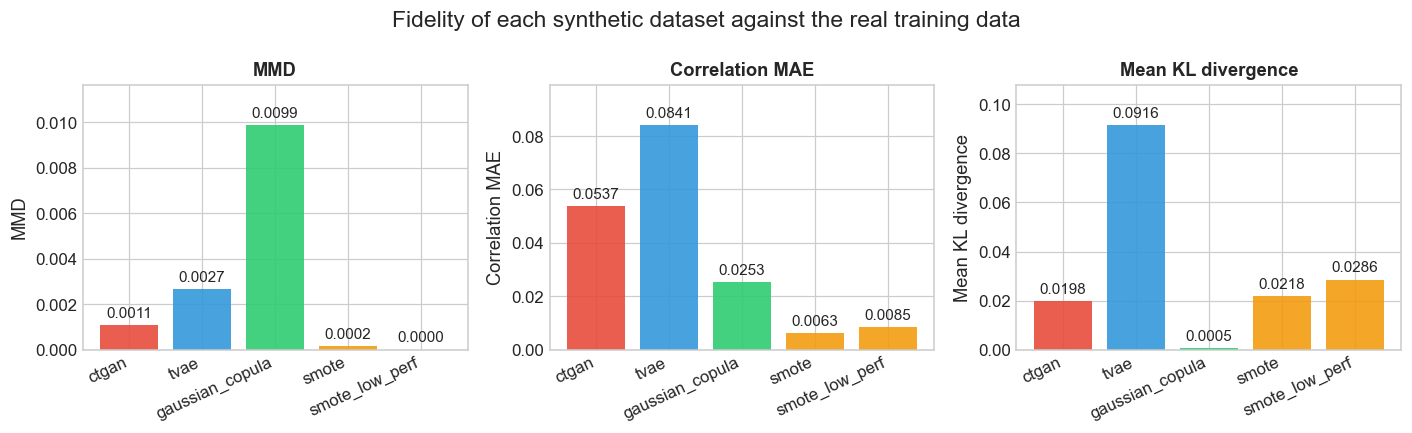

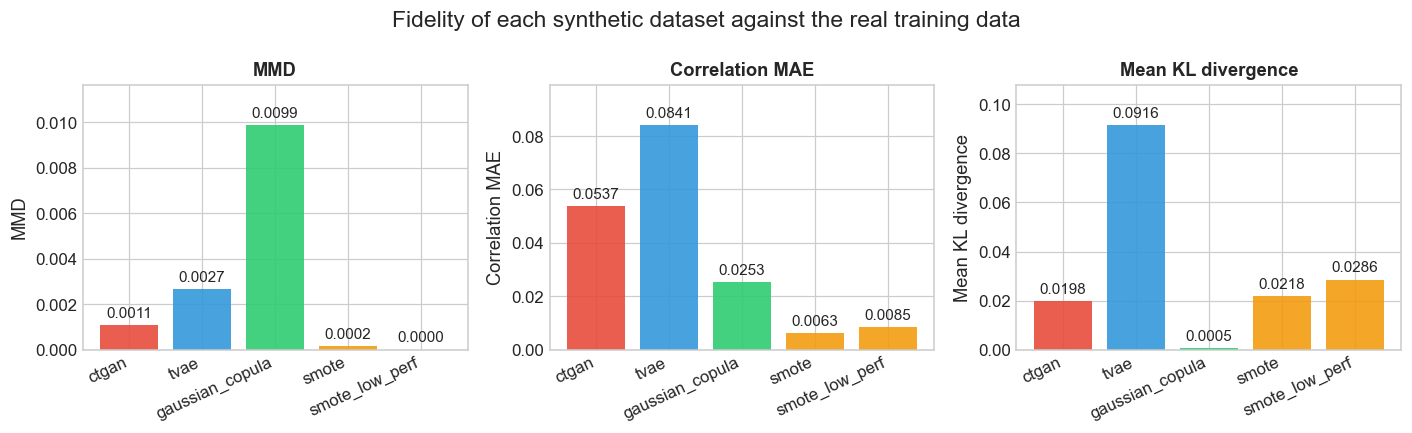

In [12]:
from src.utils.plotting import plot_fidelity_summary

plot_fidelity_summary(table, FIGURES_DIR)

### 5.1 KL divergence in protected attributes

If a generator moves the frequency of a circumstance, it moves the group sizes the fairness metrics are built on.

In [13]:
from src.generation.metadata import categorical_columns

categorical_protected = [
    c for c in cfg["dataset"]["protected_attributes"]
    if c in set(categorical_columns(train_df, cfg))
]
protected_kl = kl_table(reports, categorical_protected + list(TARGETS.values()))
print("KL divergence, real against synthetic, lower is better:")
print(protected_kl.round(4).to_string())

KL divergence, real against synthetic, lower is better:
                                                    ctgan    tvae  gaussian_copula   smote  smote_low_perf
s_gender                                           0.0001  0.5113           0.0000  0.0008          0.0001
f_mother_education_level                           0.0630  0.0626           0.0001  0.0495          0.0805
f_father_education_level                           0.0245  0.0436           0.0001  0.0684          0.1035
f_mother_occupation                                0.0141  0.0423           0.0001  0.0269          0.0434
f_father_occupation                                0.0154  0.0149           0.0001  0.0269          0.0543
s_birth_country                                    0.0606  0.1592           0.0118  0.0429          0.0417
f_start_schooling_age                              0.0138  0.0846           0.0000  0.0288          0.0160
f_extent_of_books_at_home                          0.0166  0.0170           0.0000  0.02

## 6. Visualising the synthetic datasets

2026-07-27 15:54:34 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\class_balance_target_high_perf.png


2026-07-27 15:54:35 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\class_balance_target_low_perf.png


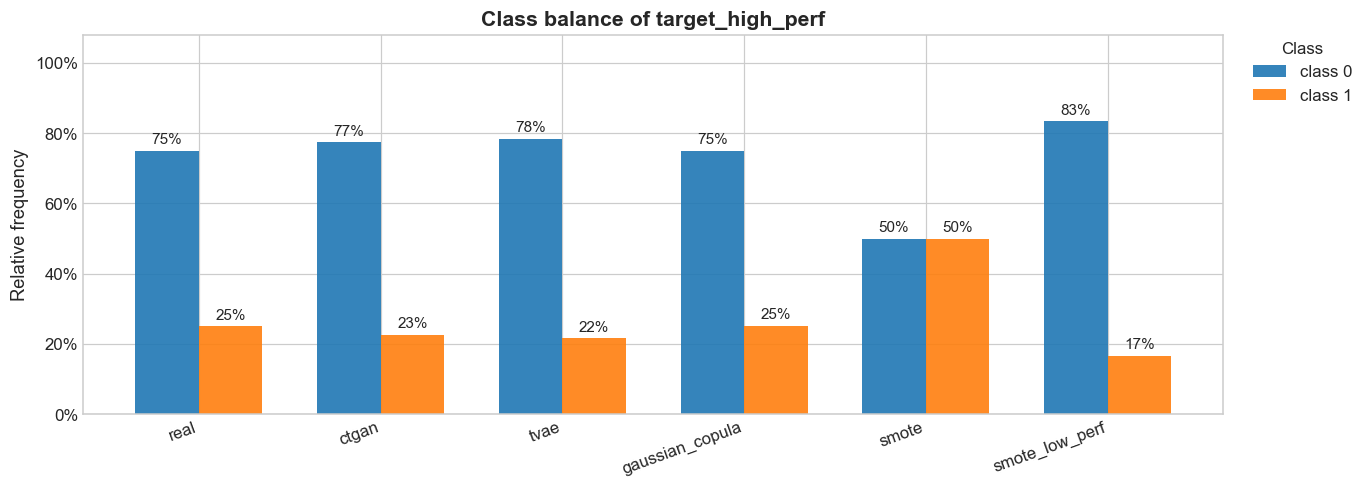

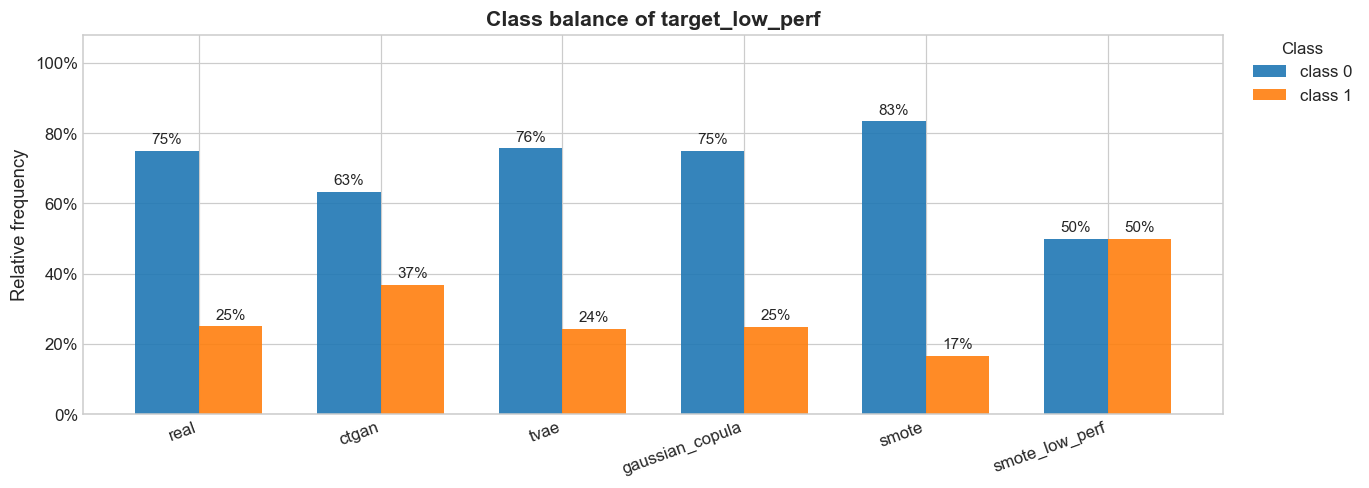

In [14]:
from src.utils.plotting import plot_class_balance, plot_marginal_distributions

for name, column in TARGETS.items():
    plot_class_balance(train_df, synthetic, column, FIGURES_DIR)

2026-07-27 15:54:36 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\marginal_target_high_perf.png


2026-07-27 15:54:37 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\marginal_target_low_perf.png


2026-07-27 15:54:38 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\marginal_s_gender.png


2026-07-27 15:54:39 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g2\marginal_f_ESCS.png


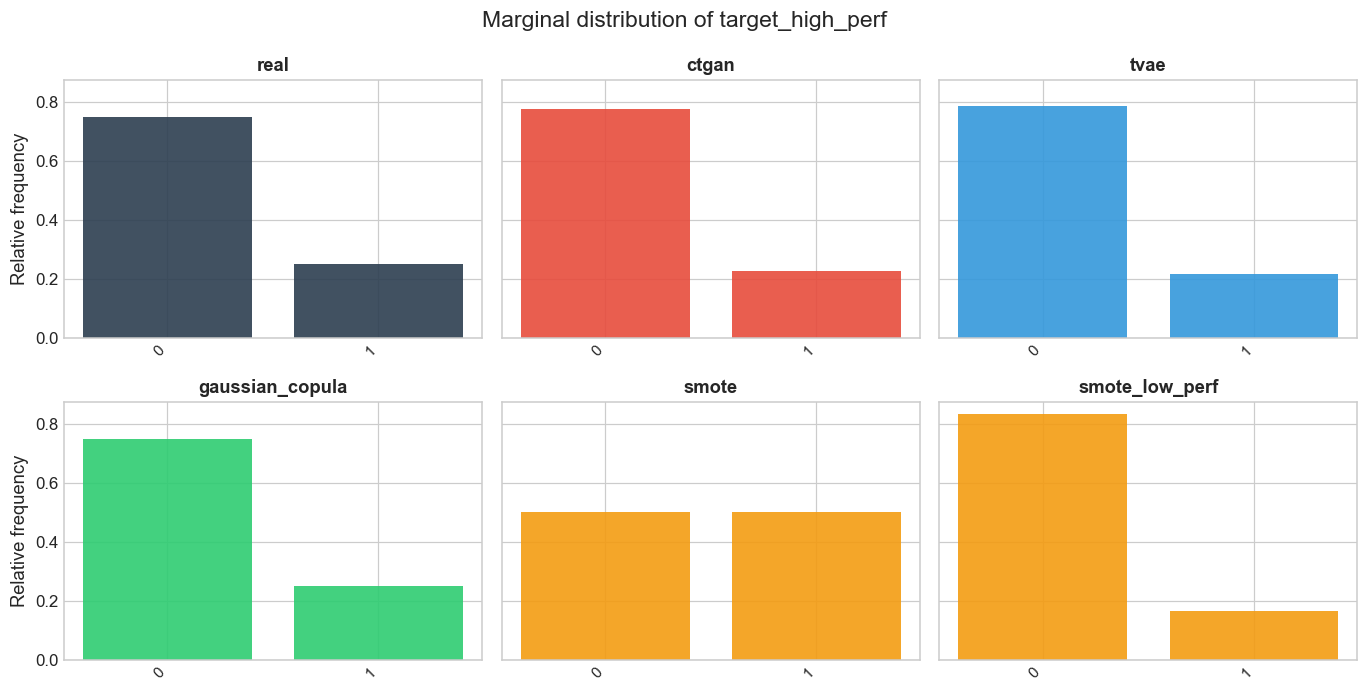

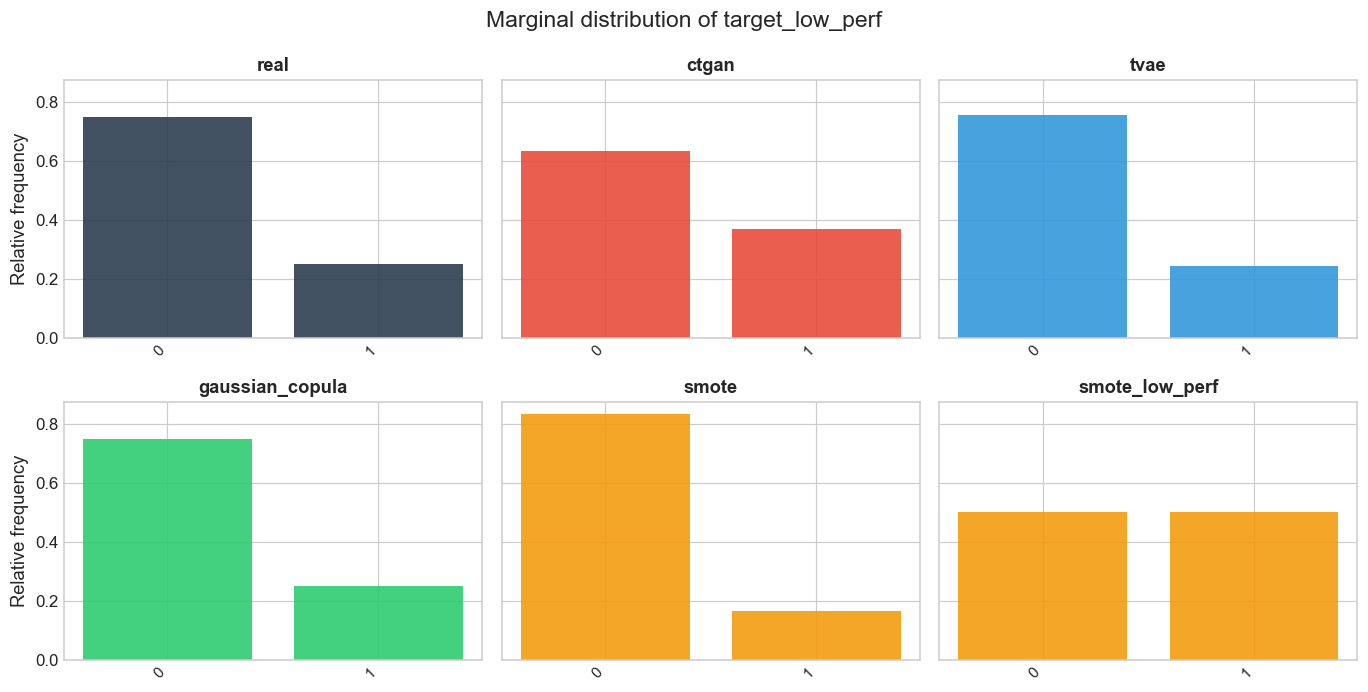

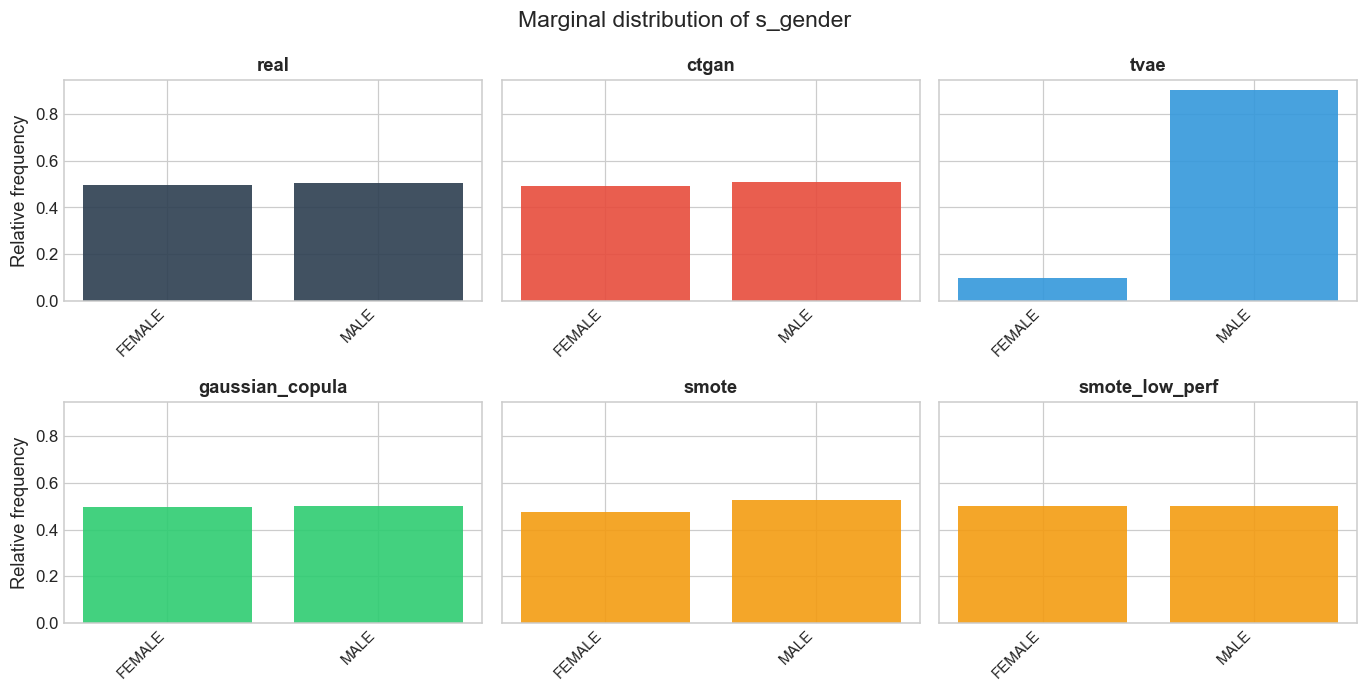

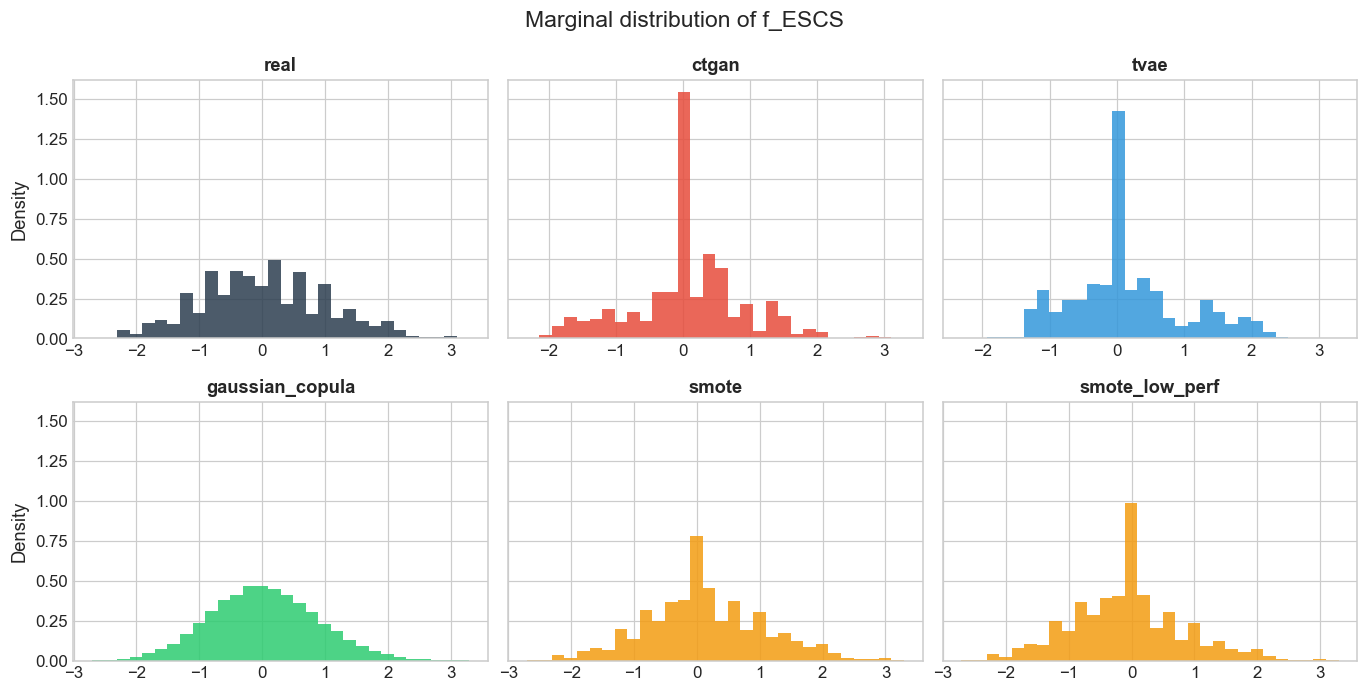

In [15]:
for column in list(TARGETS.values()) + ["s_gender", "f_ESCS"]:
    plot_marginal_distributions(train_df, synthetic, column, cfg, FIGURES_DIR)

## 7. SMOTE and the minority it interpolates inside

SMOTE only creates rows for the minority class, by interpolating between members of that class
and their nearest neighbours. So whatever the minority class looks like demographically, the
synthetic rows look more like its dense centre and less like its edges.

That is worth checking on both variants, because the minority class is a different population
in each. On the excellence task it is the top quarter, which skews advantaged. On the
underperformance task it is the bottom quarter, which skews disadvantaged, and that is the
group this project is most concerned about.

In [16]:
def minority_shift(real_df, smote_df, target, attributes):
    """How the composition of the minority class changes once SMOTE has filled it in."""
    rows = []
    for attr in attributes:
        real_share = real_df.loc[real_df[target] == 1, attr].value_counts(normalize=True)
        smote_share = smote_df.loc[smote_df[target] == 1, attr].value_counts(normalize=True)
        for value in real_share.index:
            rows.append({
                "attribute": attr,
                "value": value,
                "real": real_share.get(value, 0.0),
                "smote": smote_share.get(value, 0.0),
            })
    out = pd.DataFrame(rows)
    out["shift"] = out["smote"] - out["real"]
    return out.reindex(out["shift"].abs().sort_values(ascending=False).index)


attributes = ["f_mother_education_level", "f_father_occupation", "f_extent_of_books_at_home", "s_gender"]

for task_name, method in [("high_perf", "smote"), ("low_perf", "smote_low_perf")]:
    target = TARGETS[task_name]
    print(f"\n{method}, largest shifts inside the minority class of {target}:")
    print(minority_shift(train_df, synthetic[method], target, attributes)
          .head(8).round(3).to_string(index=False))


smote, largest shifts inside the minority class of target_high_perf:
                attribute value  real  smote  shift
 f_mother_education_level   4.0 0.242  0.494  0.252
f_extent_of_books_at_home  0.25 0.340  0.566  0.226
      f_father_occupation   3.0 0.554  0.746  0.192
      f_father_occupation   4.0 0.332  0.210 -0.122
f_extent_of_books_at_home   0.5 0.249  0.180 -0.069
      f_father_occupation   2.0 0.109  0.043 -0.067
f_extent_of_books_at_home  0.75 0.154  0.096 -0.058
 f_mother_education_level   3.0 0.160  0.108 -0.051

smote_low_perf, largest shifts inside the minority class of target_low_perf:
                attribute value  real  smote  shift
 f_mother_education_level   4.0 0.260  0.599  0.340
f_extent_of_books_at_home  0.25 0.440  0.717  0.277
      f_father_occupation   3.0 0.598  0.859  0.262
      f_father_occupation   2.0 0.196  0.069 -0.127
      f_father_occupation   4.0 0.191  0.068 -0.123
f_extent_of_books_at_home   0.0 0.250  0.141 -0.109
 f_mother_education_

**Observation.** The shifts are read as shares of the students who answered, so a positive
shift means a category grew relative to the other answers, not that more students gave it.

Two mechanisms push in the same direction here. For a categorical column SMOTENC gives a new
row the most common value among its neighbours, so common categories gain and rare ones lose.
And a student who left the question blank is given the column's most common value for the
neighbour search, which adds to the same category again.

The direction is towards whichever category is most common inside the minority class, and that
is not the same as towards advantage. On the excellence task the category that grows most for
parental education is the middle of the scale rather than the top, and the highest occupation
category loses ground even though it is the privileged one. So this is not SMOTE making top
students look more advantaged; it is SMOTE making them look more alike.

That is still a problem for what comes next. Every group the fairness metrics are built on is a
category of one of these columns, and the categories that shrink are the ones that were already
thinly populated. G3 and G4 then measure group differences on a training distribution where the
smaller groups have been compressed towards the middle, which is where those measurements are
least stable to begin with.

## 8. Final observations

- The exclusivity constraint held everywhere, so the two tasks can be evaluated on the same
  synthetic files without contradiction.
- The copula preserves both target rates and the two deep generators do not, so some of what
  G3 measures as a utility loss is a change in prevalence rather than a change in the signal.
- Good fidelity is not the same as good utility. The numbers here say only that the tables
  resemble each other; whether a classifier can learn from them is the subject of G3.
- SMOTE removes missingness from the rows it creates and concentrates the minority class on
  its most common categories. Both effects push against what G1 established about who is
  missing from this dataset.